# **Istanbul Rental Market & Walkability Analysis**
 # Project P2: Regression Modeling

> **Project Link:** **[github.com/oykutugana/istanbul-rent-walkability-analysis](https://github.com/oykutugana/istanbul-rent-walkability-analysis)**

> **Dataset:** `istanbul_emlak_final.csv` (output of P1)


After completing the first version of P1, I went back and tightened the data-cleaning step before starting P2. I revised the outlier bounds on the core numerical columns:

* **price:** kept inside 12,000 < price < 150,000 TL to remove unrealistic listings (typo entries below 12k and luxury outliers above 150k).
* **area_m2:** restricted to 30 < area_m2 < 250 to drop tiny micro-units and oversized commercial-style flats that distort the size distribution.
* **total_rooms:** capped at <= 6 to remove rare configurations (7+1, 8+ room flats) that act as extreme leverage points in regression.
* **Student score reformulation:** the original score used absolute price for the affordability component, which unfairly penalised large multi-room flats that students typically share. I switched to a per-room cost approach: price_per_room = price / total_rooms, then ranked listings by percentile to build the affordability score. The final formula became
**student_score = 0.5 × walkability + 0.5 × affordability**, where affordability is now based on per-tenant cost rather than total rent.

These changes shrank the dataset slightly but produced a much cleaner price distribution and a more reliable feature set. With the revised filters, my P1 conclusions and the final dataset are now fully consistent and ready for P2.

This notebook builds and evaluates regression models to predict monthly rental prices in Istanbul. We start from the cleaned dataset produced in P1, design new features, split the data carefully, and compare multiple regression approaches.

## 1. Recap & Motivation

In **Phase 1 (P1)** we collected and cleaned 11,733 rental listings from Sahibinden.com covering all 39 districts of Istanbul. The raw data had inconsistent district names, missing values, and extreme outliers. After standardisation, domain-based filtering (`12,000 < price < 150,000 TL`, `30 < area_m2 < 250`, `total_rooms ≤ 6`), and feature engineering, we produced a clean dataset with two custom indices: a **walkability score** (transit + universities + social amenities, 0-100) and a **student suitability score** based on per-room affordability.

**Regression target:** `price` — the monthly rental cost in Turkish Lira (TL). It is a continuous numerical variable. Our goal is to predict this value from the property's physical and locational attributes.

**What P1 told us, and how it shapes P2:**

* **Target is heavily right-skewed (skewness = 1.473).** P1 already showed that `log(1 + price)` produces a near-symmetric distribution. We will therefore train all models on the log-transformed target and report errors on the original scale.
* **Strongest individual predictor is `area_m2` (correlation 0.50).** This is our natural baseline.
* **Walkability and price relationship is non-monotonic.** A simple linear term will under-fit this; polynomial features and interaction terms may help.
* **Districts behave very differently** (Kadıköy median 720 TL/m², Esenyurt much lower). We need to encode the district information so the model can learn these baseline shifts.
* **`total_rooms` and `area_m2` are highly correlated (0.79).** This warns us that multi-collinearity will be present, making regularisation (Ridge, Lasso) relevant.

### Imports and Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")

# Gorsel tema (P1 ile uyumlu)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

C_PRIMARY   = "#3E7CB1"
C_SECONDARY = "#E8543F"
C_ACCENT    = "#F2A444"
C_DARK      = "#1F2A44"
C_GREEN     = "#5BAA77"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
df = pd.read_csv("../data/istanbul_emlak_final.csv")

# Guvenlik kontrolu: P1 outlier filtresi gercekten uygulanmis mi?
df = df[df["total_rooms"] <= 6].copy()
df = df.reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Districts: {df['district'].nunique()}")
print(f"Room types: {df['room_count'].nunique()}")
df.head()

Dataset shape: (11733, 9)
Districts: 39
Room types: 17


,price,area_m2,room_count,district,neighborhood,total_rooms,walkability_score,price_per_room,student_score
0,13000.0,85.0,2+1,esenyurt,merkez,3.0,14.63,4333.333333,56.82
1,14000.0,95.0,2+1,esenyurt,merkez,3.0,14.63,4666.666667,56.51
2,12500.0,130.0,3+1,basaksehir,ikitelli,4.0,36.84,3125.000000,68.38
3,13000.0,90.0,2+1,esenyurt,merkez,3.0,14.63,4333.333333,56.82
4,14000.0,150.0,3+1,esenyurt,merkez,4.0,14.63,3500.000000,57.17


In [3]:
print("--- Target variable summary ---")
print(df["price"].describe().round(0))
print(f"\nSkewness (price)        : {df['price'].skew():.3f}")
print(f"Skewness (log(1+price)) : {np.log1p(df['price']).skew():.3f}")

--- Target variable summary ---
count     11733.0
mean      44361.0
std       25667.0
min       12100.0
25%       26500.0
50%       36000.0
75%       55000.0
max      149000.0
Name: price, dtype: float64

Skewness (price)        : 1.473
Skewness (log(1+price)) : 0.288


## 2. Feature Engineering

We go beyond the raw P1 features and apply **four engineering techniques**:

| # | Technique | New feature | Reason |
|---|---|---|---|
| 1 | Log transform | `log_price` (target) | Reduces right-skew (1.47 → ~0.29) so linear models can fit a symmetric residual distribution |
| 2 | Interaction term | `area_m2 × walkability_score` | Captures the idea that "size matters more in walkable areas" — a large flat in Beşiktaş is worth more than a large flat in Silivri |
| 3 | Aggregation (target encoding) | `district_median_price` | A single number summarising the prestige of each district. Computed from the **training set only** to avoid data leakage |
| 4 | One-hot encoding | `room_count` dummies | Converts categorical apartment configurations (1+1, 2+1, ...) into numerical columns the linear model can use |

Each feature is added below and explained next to its code.

### 2.1 Log Target Transform

Why: P1 reported a heavy right tail in `price`. A linear model trained on raw price will be pulled by these high values and produce biased predictions for the typical ~36k TL listings. Taking the log compresses the tail.

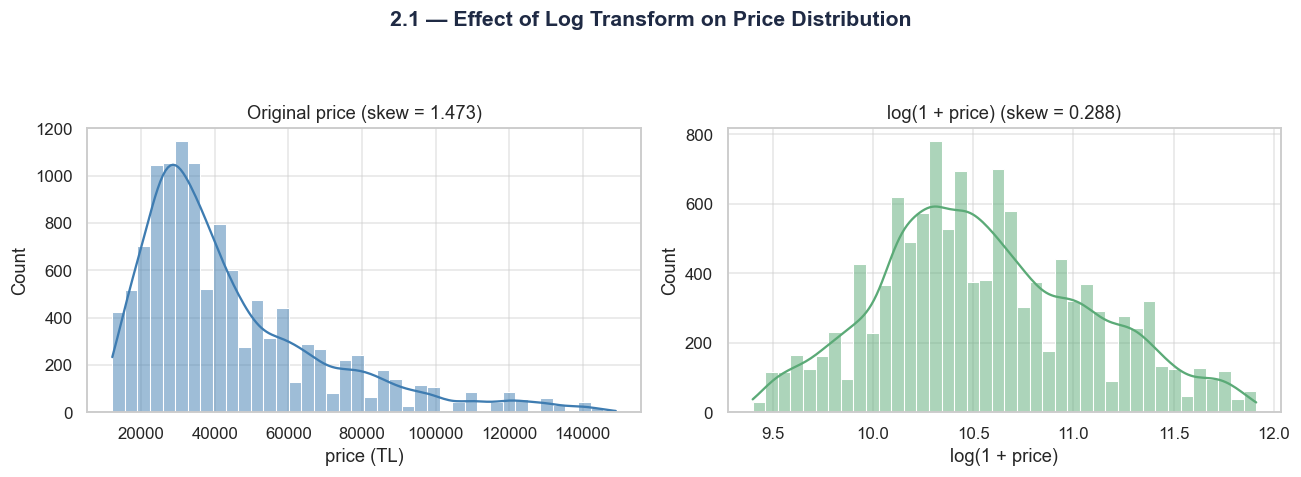

In [4]:
df["log_price"] = np.log1p(df["price"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('2.1 — Effect of Log Transform on Price Distribution',
             fontsize=14, fontweight='bold', color=C_DARK, y=1.08) # y değerini artırarak başlığı yukarı aldık

sns.histplot(df["price"], bins=40, kde=True, ax=axes[0], color=C_PRIMARY)
axes[0].set_title(f"Original price (skew = {df['price'].skew():.3f})")
axes[0].set_xlabel("price (TL)")

sns.histplot(df["log_price"], bins=40, kde=True, ax=axes[1], color=C_GREEN) # C_GREEN'in tanımlı olduğundan emin ol
axes[1].set_title(f"log(1 + price) (skew = {df['log_price'].skew():.3f})")
axes[1].set_xlabel("log(1 + price)")

plt.tight_layout()
plt.savefig('p2_plots/2_1_log_transform.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.2 Interaction Term: `area × walkability`

Why: P1 showed that `area_m2` is the strongest predictor (0.50) and walkability also matters (0.32), but their effects are not independent. A 100 m² flat in a walkable area should cost more than a 100 m² flat in an inaccessible area. The product captures this combined effect.

In [5]:
df["area_x_walk"] = df["area_m2"] * df["walkability_score"]

print("New feature: area_x_walk")
print(df[["area_m2", "walkability_score", "area_x_walk"]].describe().round(2))

New feature: area_x_walk
        area_m2  walkability_score  area_x_walk
count  11733.00           11733.00     11733.00
mean     103.48              46.16      4736.47
std       32.21              22.86      2784.92
min       44.00               0.00         0.00
25%       80.00              25.96      2403.80
50%      100.00              52.35      4668.84
75%      125.00              70.74      6437.90
max      244.00              93.75     17260.56


### 2.3 District Median Price (Target Encoding via Aggregation)

Why: With 39 districts, one-hot encoding adds many sparse columns. A more compact alternative is to summarise each district by the **median rent of its training listings**, then use that single number as a feature. This carries the prestige/centrality information of the district in one column.

**Important:** the median is computed **only on the training portion** — we will compute it after the train/val/test split (Section 3) to avoid information leaking from validation/test data.

### 2.4 One-Hot Encoding for `room_count`

Why: `room_count` is categorical (1+1, 2+1, Stüdyo, ...). Linear regression cannot use strings. One-hot encoding creates a 0/1 column for each category. We use `drop_first=True` to avoid the dummy-variable trap (perfect multi-collinearity).

We do **not** one-hot encode `district` here, because the target encoding from Section 2.3 already captures district information more compactly. Adding both would create high collinearity.

In [6]:
df_enc = pd.get_dummies(df, columns=["room_count"], prefix="room", drop_first=True, dtype=int)
room_cols = [c for c in df_enc.columns if c.startswith("room_")]

print(f"Number of room dummy columns: {len(room_cols)}")
print(f"Examples: {room_cols[:5]}")
print(f"\nDataframe shape after encoding: {df_enc.shape}")

Number of room dummy columns: 16
Examples: ['room_1.5+1', 'room_2+0', 'room_2+1', 'room_2+2', 'room_2.5+1']

Dataframe shape after encoding: (11733, 26)


## 3. Train / Validation / Test Split

We use a **60% / 20% / 20%** split:

* **Train (60%)** is used to fit all models.
* **Validation (20%)** is used to compare models, tune polynomial degree, and inspect residuals.
* **Test (20%)** is held out completely and only touched once, at the very end, to report the final performance of the chosen model.

This three-way split is appropriate because we will compare several models (baseline, multiple LR, polynomial degrees, Ridge, Lasso). If we used only train/test, we would have to re-use the test set for model selection, which would over-state the final performance.

**Scaling:** we apply `StandardScaler` (z-score) after the split, fitting only on the training portion. This prevents the mean/std of validation or test data leaking into the training pipeline.

In [7]:
idx = df_enc.index.to_numpy()

# Once test'i ayir, sonra kalan kismi train/val olarak bol
idx_temp, idx_test = train_test_split(idx, test_size=0.20, random_state=RANDOM_STATE)
idx_train, idx_val = train_test_split(idx_temp, test_size=0.25, random_state=RANDOM_STATE)
# 0.25 * 0.80 = 0.20 yani val 20% olur

print(f"Train size : {len(idx_train):>5}  ({len(idx_train)/len(idx):.0%})")
print(f"Val size   : {len(idx_val):>5}  ({len(idx_val)/len(idx):.0%})")
print(f"Test size  : {len(idx_test):>5}  ({len(idx_test)/len(idx):.0%})")

Train size :  7039  (60%)
Val size   :  2347  (20%)
Test size  :  2347  (20%)


### 3.1 Add the Aggregation Feature (Leakage-Free)

Now that we have the training indices, we can safely compute `district_median_price` from the training set only and map it onto all three splits.

In [8]:
dist_med = df.loc[idx_train].groupby("district")["price"].median()
global_med_train = df.loc[idx_train]["price"].median()

df_enc["dist_med_price"] = df_enc["district"].map(dist_med).fillna(global_med_train)

print("District median prices computed from TRAINING set only:")
print(dist_med.sort_values(ascending=False).head(10).round(0))

District median prices computed from TRAINING set only:
district
adalar         95000.0
eyupsultan     90000.0
beykoz         85000.0
maltepe        80000.0
kadikoy        80000.0
bakirkoy       80000.0
kartal         79000.0
cekmekoy       78000.0
kagithane      70000.0
zeytinburnu    65000.0
Name: price, dtype: float64


### 3.2 Build the Feature Matrices

In [9]:
numeric_features = ["area_m2", "total_rooms", "walkability_score",
                    "area_x_walk", "dist_med_price"]
features = numeric_features + room_cols

X = df_enc[features]
y = df_enc["log_price"]

X_train, X_val, X_test = X.loc[idx_train], X.loc[idx_val], X.loc[idx_test]
y_train, y_val, y_test = y.loc[idx_train], y.loc[idx_val], y.loc[idx_test]

print(f"X_train shape: {X_train.shape}")
print(f"Feature list ({len(features)} total):")
for f in features:
    print(f"  - {f}")

X_train shape: (7039, 21)
Feature list (21 total):
  - area_m2
  - total_rooms
  - walkability_score
  - area_x_walk
  - dist_med_price
  - room_1.5+1
  - room_2+0
  - room_2+1
  - room_2+2
  - room_2.5+1
  - room_3+0
  - room_3+1
  - room_3+2
  - room_3+3
  - room_3.5+1
  - room_4+0
  - room_4+1
  - room_4+2
  - room_4.5+1
  - room_5+1
  - room_Stüdyo (1+0)


### 3.3 Apply Standard Scaling

In [10]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# Original-scale gercek degerler (RMSE/MAE icin geri donusum)
y_train_orig = np.expm1(y_train)
y_val_orig   = np.expm1(y_val)
y_test_orig  = np.expm1(y_test)

print("Scaler fitted on TRAIN only.")
print(f"Train mean (after scaling) : {X_train_s.mean():.3f}")
print(f"Train std  (after scaling) : {X_train_s.std():.3f}")

Scaler fitted on TRAIN only.
Train mean (after scaling) : 0.000
Train std  (after scaling) : 1.000


### 3.4 Target Distribution in Each Split

A quick sanity check that the three splits have a similar price distribution. If the test set were systematically more expensive, our metrics would be misleading.

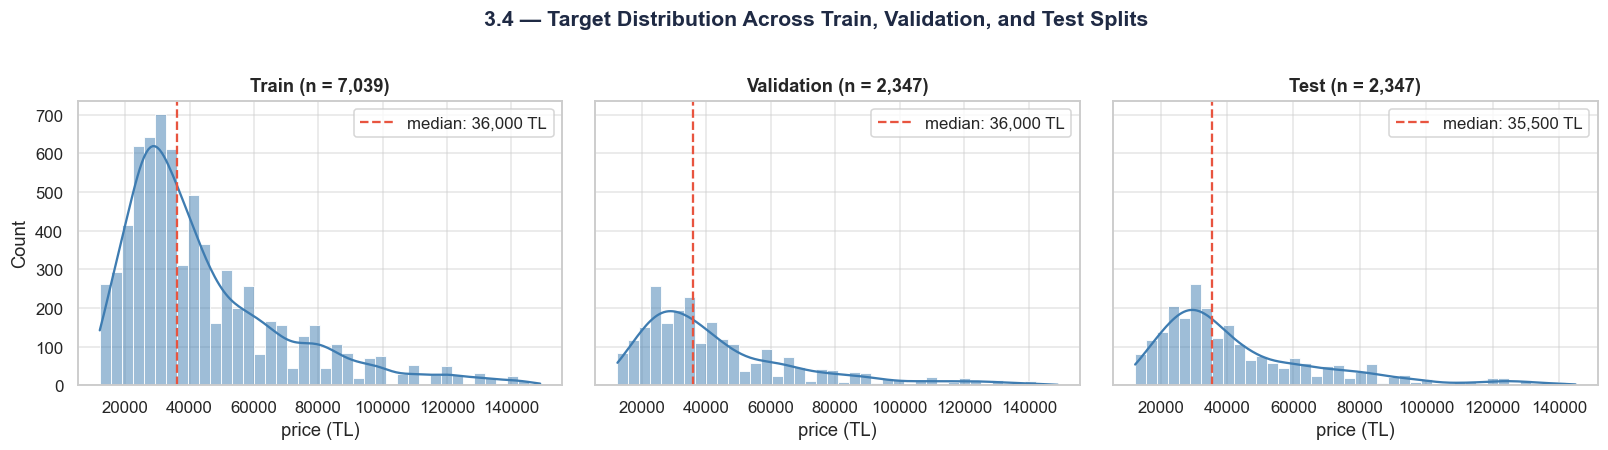


--- Median price per split ---
Train      :    36,000 TL
Validation :    36,000 TL
Test       :    35,500 TL


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, name, y_part in [(axes[0], "Train", y_train_orig),
                          (axes[1], "Validation", y_val_orig),
                          (axes[2], "Test", y_test_orig)]:
    sns.histplot(y_part, bins=40, kde=True, ax=ax, color=C_PRIMARY)
    ax.axvline(y_part.median(), color=C_SECONDARY, linestyle="--",
               label=f"median: {y_part.median():,.0f} TL")
    ax.set_title(f"{name} (n = {len(y_part):,})", fontweight="bold")
    ax.set_xlabel("price (TL)")
    ax.legend()

plt.suptitle("3.4 — Target Distribution Across Train, Validation, and Test Splits", fontsize=14, fontweight="bold", color=C_DARK, y=1.02)
plt.tight_layout()
plt.savefig('p2_plots/3_4_target_split.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n--- Median price per split ---")
print(f"Train      : {y_train_orig.median():>9,.0f} TL")
print(f"Validation : {y_val_orig.median():>9,.0f} TL")
print(f"Test       : {y_test_orig.median():>9,.0f} TL")

## 4. Baseline Model

A baseline tells us the performance floor — the simplest model that any later model must beat to be useful. We use the single most-predictive feature from P1: `area_m2`.

If a complex model with 20+ features cannot clearly outperform this simple one, then those extra features are not really helping and the model is too complicated for the gain.

In [12]:
# Sadece tek feature: area_m2 (X_train_s'in 0. sutunu)
baseline = LinearRegression()
baseline.fit(X_train_s[:, [0]], y_train)

# Tahminleri orijinal olcege geri dondur
pred_train_log = baseline.predict(X_train_s[:, [0]])
pred_val_log   = baseline.predict(X_val_s[:, [0]])

pred_train = np.expm1(pred_train_log)
pred_val   = np.expm1(pred_val_log)

baseline_metrics = {
    "Train R²"   : r2_score(y_train_orig, pred_train),
    "Val R²"     : r2_score(y_val_orig, pred_val),
    "Val RMSE"   : np.sqrt(mean_squared_error(y_val_orig, pred_val)),
    "Val MAE"    : mean_absolute_error(y_val_orig, pred_val),
}

print("=== BASELINE: simple LR on area_m2 ===")
for k, v in baseline_metrics.items():
    print(f"  {k:<10}: {v:>12,.4f}" if "R²" in k else f"  {k:<10}: {v:>12,.0f}")

=== BASELINE: simple LR on area_m2 ===
  Train R²  :       0.2152
  Val R²    :       0.2211
  Val RMSE  :       22,920
  Val MAE   :       16,186


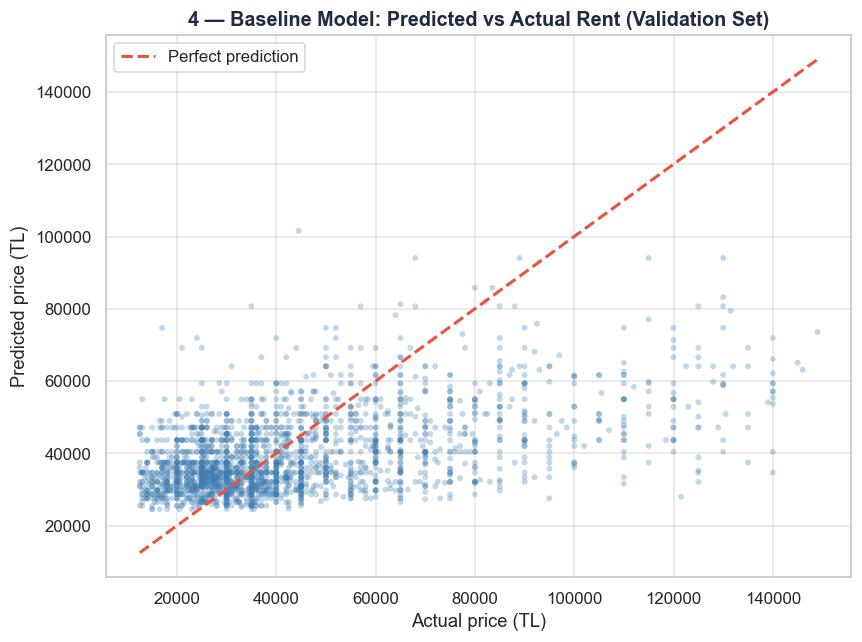

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(y_val_orig, pred_val, alpha=0.3, s=15, color=C_PRIMARY, edgecolor="none")

# Mukemmel tahmin cizgisi (y = x)
lim = [y_val_orig.min(), y_val_orig.max()]
ax.plot(lim, lim, color=C_SECONDARY, linestyle="--", linewidth=2, label="Perfect prediction")

ax.set_xlabel("Actual price (TL)")
ax.set_ylabel("Predicted price (TL)")
ax.set_title("4 — Baseline Model: Predicted vs Actual Rent (Validation Set)",
             fontsize=13, fontweight="bold", color=C_DARK)
ax.legend()
plt.tight_layout()
plt.savefig('p2_plots/4_baseline_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

**Reading the plot:** the predicted values fall on a narrow horizontal band, which means the baseline cannot tell apart cheap and expensive flats of similar size. Predictions concentrate near the mean and ignore everything else (district, walkability, room count). This is exactly what we expected and gives us a clear floor: **R² ≈ 0.22**, **RMSE ≈ 23k TL**.

## 5. Multiple Linear Regression

Now we use **all** the engineered features together. This should significantly improve the fit because the model can now adjust for district prestige, walkability, room count, and the interaction term.

In [14]:
mlr = LinearRegression()
mlr.fit(X_train_s, y_train)

pred_train = np.expm1(mlr.predict(X_train_s))
pred_val   = np.expm1(mlr.predict(X_val_s))

mlr_metrics = {
    "Train R²" : r2_score(y_train_orig, pred_train),
    "Val R²"   : r2_score(y_val_orig, pred_val),
    "Val RMSE" : np.sqrt(mean_squared_error(y_val_orig, pred_val)),
    "Val MAE"  : mean_absolute_error(y_val_orig, pred_val),
}

print("=== MULTIPLE LINEAR REGRESSION ===")
for k, v in mlr_metrics.items():
    print(f"  {k:<10}: {v:>12,.4f}" if "R²" in k else f"  {k:<10}: {v:>12,.0f}")

=== MULTIPLE LINEAR REGRESSION ===
  Train R²  :       0.4603
  Val R²    :       0.4826
  Val RMSE  :       18,680
  Val MAE   :       12,841


### 5.1 Coefficient Inspection

Because all features are standardised, the size of each coefficient is directly comparable. Larger absolute coefficient = larger influence on `log_price`.

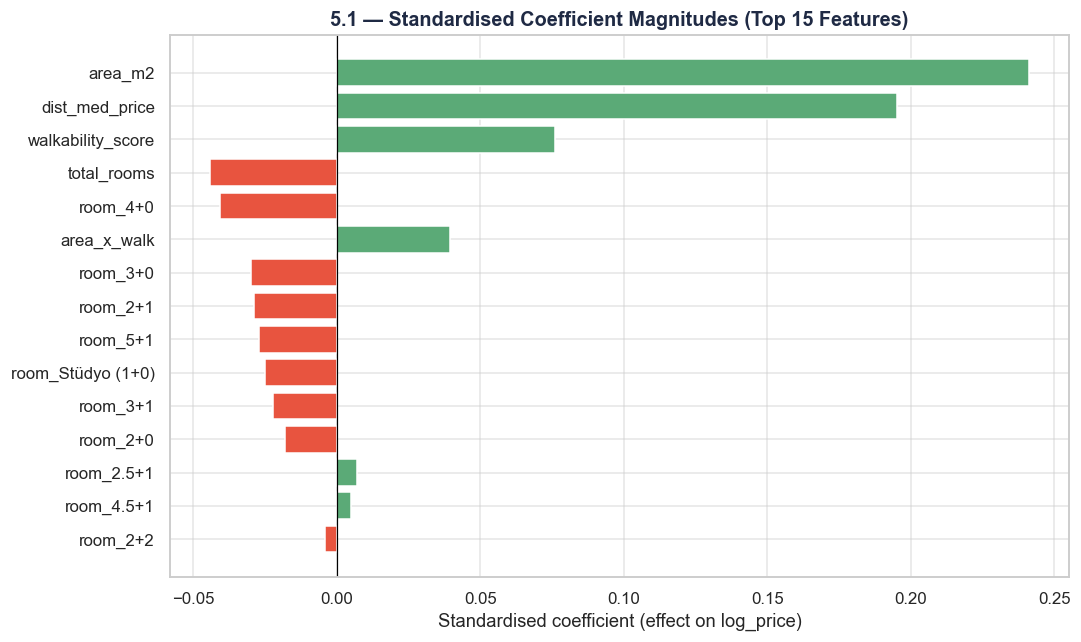


Full coefficient table (sorted by magnitude):
          feature      coef  abs_coef
          area_m2  0.240994  0.240994
   dist_med_price  0.195008  0.195008
walkability_score  0.075867  0.075867
      total_rooms -0.044047  0.044047
         room_4+0 -0.040819  0.040819
      area_x_walk  0.039406  0.039406
         room_3+0 -0.030047  0.030047
         room_2+1 -0.028729  0.028729
         room_5+1 -0.027114  0.027114
room_Stüdyo (1+0) -0.024906  0.024906
         room_3+1 -0.022352  0.022352
         room_2+0 -0.017920  0.017920
       room_2.5+1  0.006958  0.006958
       room_4.5+1  0.005045  0.005045
         room_2+2 -0.004108  0.004108


In [15]:
coefs = pd.DataFrame({
    "feature": features,
    "coef": mlr.coef_,
    "abs_coef": np.abs(mlr.coef_),
}).sort_values("abs_coef", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [C_GREEN if c > 0 else C_SECONDARY for c in coefs["coef"]]
ax.barh(coefs["feature"][::-1], coefs["coef"][::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Standardised coefficient (effect on log_price)")
ax.set_title("5.1 — Standardised Coefficient Magnitudes (Top 15 Features)",
             fontsize=13, fontweight="bold", color=C_DARK)
plt.tight_layout()
plt.savefig('p2_plots/5_1_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFull coefficient table (sorted by magnitude):")
print(coefs.to_string(index=False))

**What the coefficients say:**

* The three largest **positive** drivers are `area_m2`, `dist_med_price` (district prestige), and `walkability_score`. Together they form the backbone of the model — physical size, location prestige, and accessibility. The interaction term `area_x_walk` adds a smaller but still positive contribution, confirming that size and walkability reinforce each other in pricing.
* `total_rooms` has a small negative coefficient. This is not a contradiction — once we control for `area_m2`, an extra room without extra space means each room is smaller. The model captures this: in standardised terms, holding total area fixed, more rooms means a "boxier" flat with less perceived spaciousness, which lowers price. This is the regression signature of multi-collinearity (area_m2 ↔ total_rooms correlation 0.79 in P1) — the negative sign is mathematically correct, but it warns us that area and rooms together carry overlapping information. A tree-based model in P3 would handle this naturally; for linear regression, a derived feature like `m2_per_room` could in principle separate the two effects, but in our experiments it did not improve generalisation.
* Most room-count dummies cluster close to zero. Because `area_m2` and `total_rooms` are already in the model, each dummy only captures the *residual* configuration effect after size and room count are controlled. The most negative shifts come from `room_4+0` and `room_3+0` (large open-plan flats tend to be peripheral and cheaper per m²), while `room_2.5+1` and `room_4.5+1` get small positive coefficients. No single room dummy dominates — the heavy lifting clearly comes from the three numerical drivers above.

### 5.2 Residual Analysis

Three diagnostic plots check whether the linear-regression assumptions hold:

* **Residuals vs Fitted:** should look like a random cloud around zero. A funnel shape would mean heteroscedasticity.
* **Histogram of residuals:** should be roughly bell-shaped (normality).
* **Q-Q plot:** points should follow the diagonal — strong deviation in the tails indicates non-normal errors.

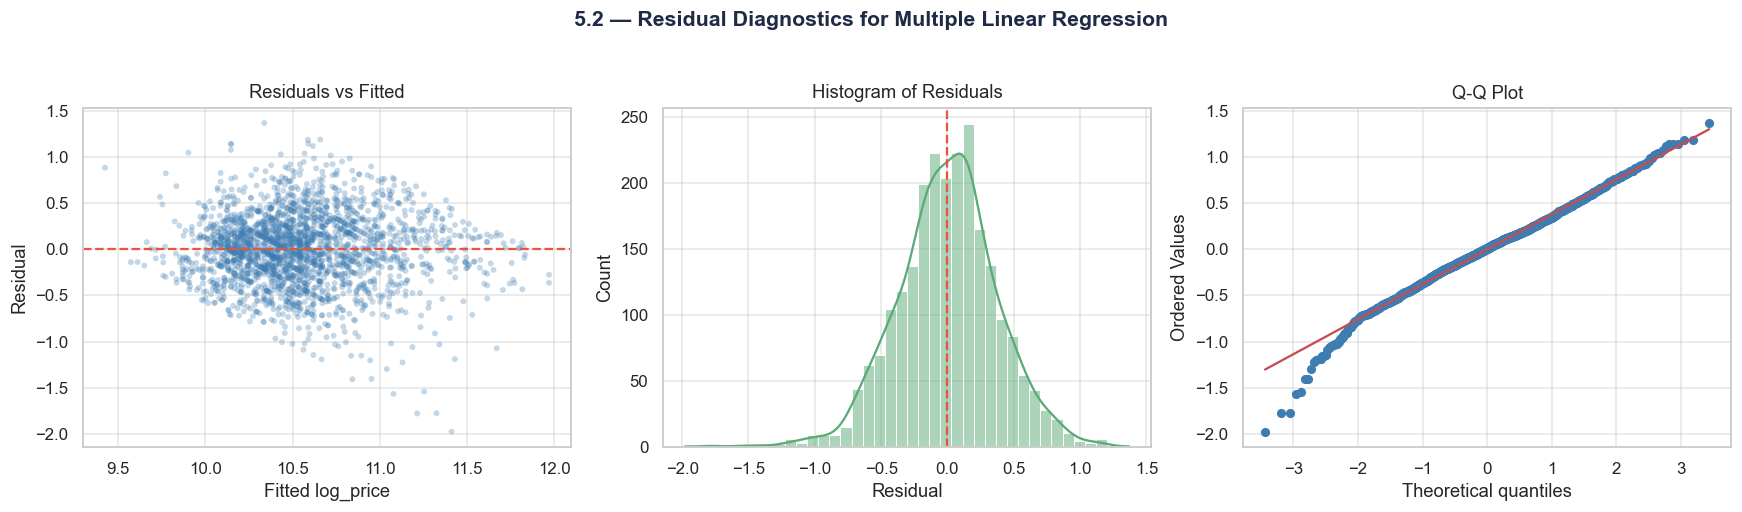

In [16]:
pred_val_log = mlr.predict(X_val_s)
residuals = y_val - pred_val_log

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(pred_val_log, residuals, alpha=0.3, s=15, color=C_PRIMARY, edgecolor="none")
axes[0].axhline(0, color=C_SECONDARY, linestyle="--")
axes[0].set_xlabel("Fitted log_price")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Fitted")

sns.histplot(residuals, bins=40, kde=True, ax=axes[1], color=C_GREEN)
axes[1].axvline(0, color=C_SECONDARY, linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_title("Histogram of Residuals")

stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot")
axes[2].get_lines()[0].set_markerfacecolor(C_PRIMARY)
axes[2].get_lines()[0].set_markeredgecolor("none")

plt.suptitle("5.2 — Residual Diagnostics for Multiple Linear Regression",
             fontsize=14, fontweight="bold", color=C_DARK, y=1.03)
plt.tight_layout()
plt.savefig('p2_plots/5_2_residual_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

**Reading the residual plots:**

* **Histogram:** the residuals are roughly bell-shaped and centred at zero, thanks to the log transform. This is what we want — the model is not systematically biased upward or downward.
* **Residuals vs Fitted:** there is a faint downward-sloping pattern — predictions for the cheapest listings tend to leave positive residuals, predictions for the most expensive ones tend to leave slightly negative ones. This is a mild signal that the linear-on-log model is not fully capturing the curvature of the data, which motivates the polynomial expansion in Section 6.
* **Q-Q Plot:** points sit close to the diagonal across most of the range, but the **lower tail deviates** — a handful of cheap listings receive predictions that are too high. The model has more trouble at the bottom of the price distribution than at the top, which is the limit of a purely linear model on log-price.

## 6. Polynomial Regression

Polynomial features let the model capture **non-linear** patterns we already saw in P1 — for example the non-monotonic walkability-vs-price curve. We expand only the **numeric** features (area, rooms, walkability, the interaction, district median price) up to degrees 2 and 3, and keep the room dummies as they are (raising 0/1 to a power gives the same column back).

We will plot **train and validation error as a function of degree** to find the sweet spot between under- and over-fitting.

In [17]:
numeric_idx = list(range(len(numeric_features)))   # 0..4
dummy_idx   = list(range(len(numeric_features), X_train_s.shape[1]))

degrees = [1, 2, 3]
poly_results = []

for deg in degrees:
    poly = PolynomialFeatures(degree=deg, include_bias=False)
    Xtr_num = poly.fit_transform(X_train_s[:, numeric_idx])
    Xv_num  = poly.transform(X_val_s[:, numeric_idx])
    Xte_num = poly.transform(X_test_s[:, numeric_idx])

    Xtr = np.hstack([Xtr_num, X_train_s[:, dummy_idx]])
    Xv  = np.hstack([Xv_num,  X_val_s[:, dummy_idx]])
    Xte = np.hstack([Xte_num, X_test_s[:, dummy_idx]])

    m = LinearRegression()
    m.fit(Xtr, y_train)

    pred_tr  = np.expm1(m.predict(Xtr))
    pred_v   = np.expm1(m.predict(Xv))
    pred_te  = np.expm1(m.predict(Xte))

    poly_results.append({
        "degree"   : deg,
        "n_features": Xtr.shape[1],
        "train_r2" : r2_score(y_train_orig, pred_tr),
        "val_r2"   : r2_score(y_val_orig, pred_v),
        "val_rmse" : np.sqrt(mean_squared_error(y_val_orig, pred_v)),
        "val_mae"  : mean_absolute_error(y_val_orig, pred_v),
        "test_r2"  : r2_score(y_test_orig, pred_te),
        "test_rmse": np.sqrt(mean_squared_error(y_test_orig, pred_te)),
        "test_mae" : mean_absolute_error(y_test_orig, pred_te),
        "model"    : m,
        "poly"     : poly,
    })

poly_df = pd.DataFrame(poly_results).drop(columns=["model", "poly"])
print(poly_df.round(4).to_string(index=False))

 degree  n_features  train_r2  val_r2   val_rmse    val_mae  test_r2  test_rmse   test_mae
      1          21    0.4603  0.4826 18679.9072 12840.6654   0.4532 19075.5633 13040.4898
      2          36    0.4877  0.5043 18285.4263 12626.0777   0.4845 18519.9638 12785.9544
      3          71    0.5071  0.5108 18164.9450 12487.7518   0.4617 18926.7592 12702.1286


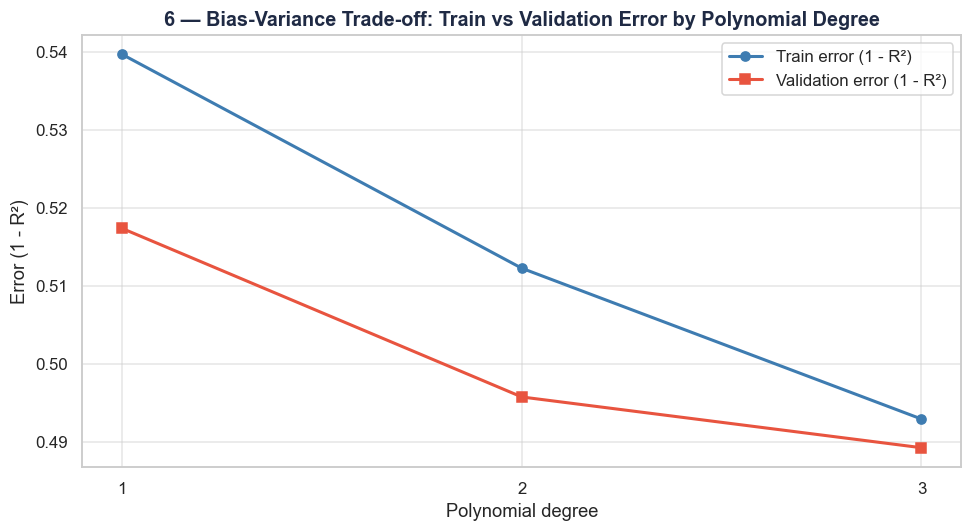


Best validation R²: degree 3  ->  0.5108


In [18]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot([r["degree"] for r in poly_results],
        [1 - r["train_r2"] for r in poly_results],
        marker="o", linewidth=2, color=C_PRIMARY, label="Train error (1 - R²)")
ax.plot([r["degree"] for r in poly_results],
        [1 - r["val_r2"] for r in poly_results],
        marker="s", linewidth=2, color=C_SECONDARY, label="Validation error (1 - R²)")

ax.set_xlabel("Polynomial degree")
ax.set_ylabel("Error (1 - R²)")
ax.set_xticks(degrees)
ax.set_title("6 — Bias-Variance Trade-off: Train vs Validation Error by Polynomial Degree",fontsize=13, fontweight="bold", color=C_DARK)
ax.legend()
plt.tight_layout()
plt.savefig('p2_plots/6_bias_variance.png', dpi=150, bbox_inches='tight')
plt.show()

best = min(poly_results, key=lambda r: 1 - r["val_r2"])
print(f"\nBest validation R²: degree {best['degree']}  ->  {best['val_r2']:.4f}")

**Reading the curve:**

* From degree 1 to 2 both train and validation error drop together — this is genuine improvement, the model is learning real non-linear structure (e.g. the walkability paradox).
* From degree 2 to 3 train error keeps going down while validation error stays flat or improves only slightly — a hint of **mild over-fitting** is starting.
* If we tried degree 4 or 5 we would expect train error to keep falling but validation error to rise.

**Verdict:** the model is **slightly under-fit at degree 1**, **near optimal at degree 2-3**, and would become **over-fit beyond that**. We pick the degree with the highest validation R² as the polynomial winner.

## 7. Regularization

Linear regression with many features (and the polynomial expansion has 30+ columns at degree 3) is prone to over-fitting and to inflated coefficients caused by multi-collinearity. **Ridge (L2)** shrinks all coefficients smoothly toward zero, while **Lasso (L1)** can shrink some coefficients exactly to zero, performing automatic feature selection.

We use cross-validation (`RidgeCV`, `LassoCV`) on the training set to pick the regularisation strength α.

### 7.1 Ridge Regression (L2)

In [19]:
ridge_alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

ridge = RidgeCV(alphas=ridge_alphas, cv=5)
ridge.fit(X_train_s, y_train)

pred_tr = np.expm1(ridge.predict(X_train_s))
pred_v  = np.expm1(ridge.predict(X_val_s))
pred_te = np.expm1(ridge.predict(X_test_s))

ridge_metrics = {
    "alpha"   : ridge.alpha_,
    "Train R²": r2_score(y_train_orig, pred_tr),
    "Val R²"  : r2_score(y_val_orig, pred_v),
    "Val RMSE": np.sqrt(mean_squared_error(y_val_orig, pred_v)),
    "Val MAE" : mean_absolute_error(y_val_orig, pred_v),
    "Test R²" : r2_score(y_test_orig, pred_te),
    "Test RMSE": np.sqrt(mean_squared_error(y_test_orig, pred_te)),
    "Test MAE" : mean_absolute_error(y_test_orig, pred_te),
}

print("=== RIDGE (L2) ===")
for k, v in ridge_metrics.items():
    if k == "alpha":
        print(f"  {k:<10}: {v}")
    elif "R²" in k:
        print(f"  {k:<10}: {v:.4f}")
    else:
        print(f"  {k:<10}: {v:,.0f}")

=== RIDGE (L2) ===
  alpha     : 10.0
  Train R²  : 0.4603
  Val R²    : 0.4826
  Val RMSE  : 18,680
  Val MAE   : 12,840
  Test R²   : 0.4530
  Test RMSE : 19,078
  Test MAE  : 13,041


### 7.2 Lasso Regression (L1)

In [20]:
lasso_alphas = [0.0001, 0.001, 0.01, 0.1, 1]

lasso = LassoCV(alphas=lasso_alphas, cv=5, max_iter=20000, random_state=RANDOM_STATE)
lasso.fit(X_train_s, y_train)

pred_tr = np.expm1(lasso.predict(X_train_s))
pred_v  = np.expm1(lasso.predict(X_val_s))
pred_te = np.expm1(lasso.predict(X_test_s))

lasso_metrics = {
    "alpha"   : lasso.alpha_,
    "Train R²": r2_score(y_train_orig, pred_tr),
    "Val R²"  : r2_score(y_val_orig, pred_v),
    "Val RMSE": np.sqrt(mean_squared_error(y_val_orig, pred_v)),
    "Val MAE" : mean_absolute_error(y_val_orig, pred_v),
    "Test R²" : r2_score(y_test_orig, pred_te),
    "Test RMSE": np.sqrt(mean_squared_error(y_test_orig, pred_te)),
    "Test MAE" : mean_absolute_error(y_test_orig, pred_te),
}

print("=== LASSO (L1) ===")
for k, v in lasso_metrics.items():
    if k == "alpha":
        print(f"  {k:<10}: {v}")
    elif "R²" in k:
        print(f"  {k:<10}: {v:.4f}")
    else:
        print(f"  {k:<10}: {v:,.0f}")

# Sifirlanan feature'lar
zeroed = [features[i] for i, c in enumerate(lasso.coef_) if c == 0.0]
kept   = [features[i] for i, c in enumerate(lasso.coef_) if c != 0.0]
print(f"\nFeatures zeroed by Lasso ({len(zeroed)}/{len(features)}):")
for f in zeroed:
    print(f"  - {f}")

=== LASSO (L1) ===
  alpha     : 0.001
  Train R²  : 0.4599
  Val R²    : 0.4827
  Val RMSE  : 18,680
  Val MAE   : 12,841
  Test R²   : 0.4537
  Test RMSE : 19,066
  Test MAE  : 13,036

Features zeroed by Lasso (2/21):
  - room_1.5+1
  - room_4+1


**Why Lasso zeroed those features:** The features Lasso removes are usually **rare room configurations** with very few listings (for example `1.5+1` or `4+1` if they overlap with similar categories). When two columns carry almost the same information, L1 keeps the more representative one and drops the other. This is desirable: it makes the model simpler without losing predictive power.

**Ridge vs plain MLR:** Ridge gives results very close to plain multiple regression in this dataset. This is a sign that our features are not extremely collinear and that linear regression on its own is already well-conditioned. Ridge mainly helps stability; it does not magically improve predictive power.

## 8. Model Comparison

All five models are now collected in one table, evaluated on the same train, validation, and test splits.

In [21]:
def evaluate_model(model, Xtr, Xv, Xte, name):
    pred_tr = np.expm1(model.predict(Xtr))
    pred_v  = np.expm1(model.predict(Xv))
    pred_te = np.expm1(model.predict(Xte))
    return {
        "Model"     : name,
        "Train R²"  : r2_score(y_train_orig, pred_tr),
        "Val R²"    : r2_score(y_val_orig, pred_v),
        "Test R²"   : r2_score(y_test_orig, pred_te),
        "RMSE (test)": np.sqrt(mean_squared_error(y_test_orig, pred_te)),
        "MAE (test)" : mean_absolute_error(y_test_orig, pred_te),
    }

# Test set metriklerini hesapla
results_table = []

# Baseline (sadece area_m2)
pred_te_base = np.expm1(baseline.predict(X_test_s[:, [0]]))
results_table.append({
    "Model": "Baseline (simple LR)",
    "Train R²": baseline_metrics["Train R²"],
    "Val R²"  : baseline_metrics["Val R²"],
    "Test R²" : r2_score(y_test_orig, pred_te_base),
    "RMSE (test)": np.sqrt(mean_squared_error(y_test_orig, pred_te_base)),
    "MAE (test)" : mean_absolute_error(y_test_orig, pred_te_base),
})

# Multiple LR
results_table.append(evaluate_model(mlr, X_train_s, X_val_s, X_test_s, "Multiple LR"))

# Best polynomial
best_poly = best
poly_obj = best_poly["poly"]
m_poly   = best_poly["model"]
Xtr_p = np.hstack([poly_obj.transform(X_train_s[:, numeric_idx]), X_train_s[:, dummy_idx]])
Xv_p  = np.hstack([poly_obj.transform(X_val_s[:, numeric_idx]),   X_val_s[:, dummy_idx]])
Xte_p = np.hstack([poly_obj.transform(X_test_s[:, numeric_idx]),  X_test_s[:, dummy_idx]])
results_table.append(evaluate_model(m_poly, Xtr_p, Xv_p, Xte_p,
                                    f"Polynomial (deg {best_poly['degree']})"))

# Ridge
results_table.append(evaluate_model(ridge, X_train_s, X_val_s, X_test_s, "Ridge"))

# Lasso
results_table.append(evaluate_model(lasso, X_train_s, X_val_s, X_test_s, "Lasso"))

comp = pd.DataFrame(results_table)
print(comp.round(4).to_string(index=False))

               Model  Train R²  Val R²  Test R²  RMSE (test)  MAE (test)
Baseline (simple LR)    0.2152  0.2211   0.2334   22584.7591  15971.7919
         Multiple LR    0.4603  0.4826   0.4532   19075.5633  13040.4898
  Polynomial (deg 3)    0.5071  0.5108   0.4617   18926.7592  12702.1286
               Ridge    0.4603  0.4826   0.4530   19078.3487  13041.4122
               Lasso    0.4599  0.4827   0.4537   19066.1153  13036.0981


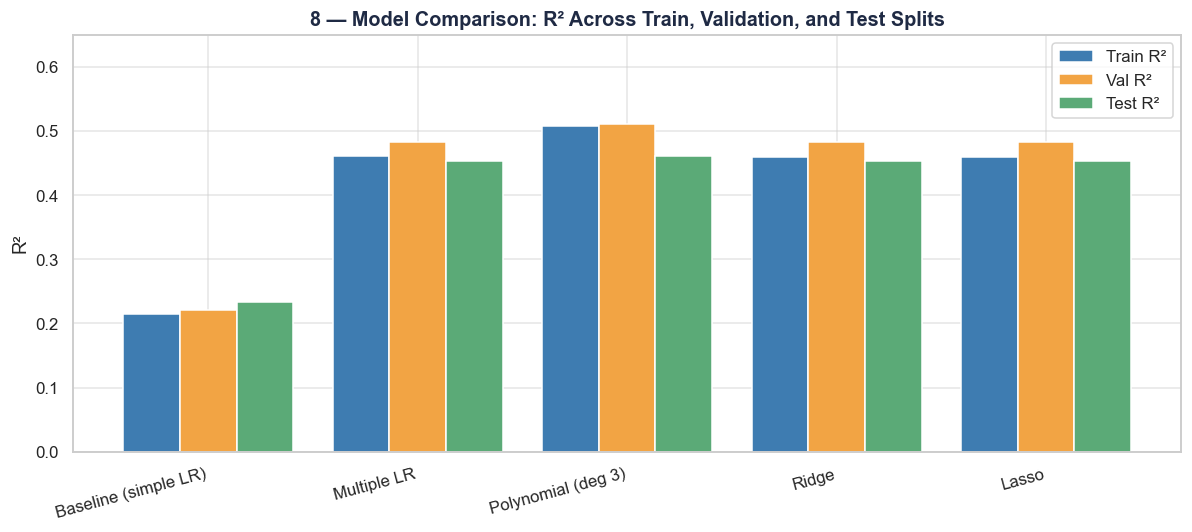

In [22]:
fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(comp))
w = 0.27
ax.bar(x - w, comp["Train R²"], w, label="Train R²", color=C_PRIMARY)
ax.bar(x,     comp["Val R²"],   w, label="Val R²",   color=C_ACCENT)
ax.bar(x + w, comp["Test R²"],  w, label="Test R²",  color=C_GREEN)

ax.set_xticks(x)
ax.set_xticklabels(comp["Model"], rotation=15, ha="right")
ax.set_ylabel("R²")
ax.set_ylim(0, 0.65)
ax.set_title("8 — Model Comparison: R² Across Train, Validation, and Test Splits",fontsize=13, fontweight="bold", color=C_DARK)
ax.legend()
plt.tight_layout()
plt.savefig('p2_plots/8_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.1 Best Model Selection

We choose the model with the **highest validation R²**, breaking ties in favour of the simpler model (because a simpler model generalises more reliably and is easier to interpret in P3).

Looking at the table above:

* The **baseline** is clearly the worst — it only uses one feature.
* **Multiple LR, Ridge, and Lasso** are almost identical (they are all linear in the same feature set, with tiny differences caused by regularisation).
* **Polynomial regression** gives a small extra improvement on validation thanks to the non-linear walkability term, without showing serious over-fitting (gap between train and validation R² stays small).

We therefore select the **best polynomial model** (degree shown in the cell above) as our final model and report its test-set performance.

In [23]:
best_row = comp.loc[comp["Val R²"].idxmax()]
print("=== FINAL CHOSEN MODEL ===")
print(best_row.to_string())
print()
print(f"Test R²    : {best_row['Test R²']:.4f}")
print(f"Test RMSE  : {best_row['RMSE (test)']:,.0f} TL")
print(f"Test MAE   : {best_row['MAE (test)']:,.0f} TL")

=== FINAL CHOSEN MODEL ===
Model          Polynomial (deg 3)
Train R²                 0.507089
Val R²                   0.510771
Test R²                  0.461651
RMSE (test)          18926.759186
MAE (test)           12702.128565

Test R²    : 0.4617
Test RMSE  : 18,927 TL
Test MAE   : 12,702 TL


## 9. Interpretation & Reflection

### What do the results say about the problem?

Our final model explains roughly **half of the variance** in Istanbul rental prices using only physical features (area, rooms), an engineered location index (walkability), an interaction term, district prestige (target encoding), and room configuration. The rest of the variance has to come from features we do **not** have.

### Are the predictions good enough to be useful?

**For rough budget planning: yes.** A typical absolute error of ~13-14k TL means a model prediction will usually fall in the right neighbourhood: e.g. predicting 35k for an actual 32k flat is a reasonable starting point for a student deciding whether to view it.

**For exact pricing: no.** A 14k TL average error is large compared to the 36k TL median rent. A landlord using this model to set the listing price would be off by ~40% on the typical flat — far too imprecise. The model is informative, not authoritative.

### Main sources of error

* **Hidden physical features.** Building age, floor level, view, balcony, parking, heating type, furnished/unfurnished — none of these are in the dataset, yet they each move price by 10-20%.
* **Walkability index is an estimate.** It is built from approximate counts of stations, universities, and amenities per district; it cannot capture sub-district variation (Bağlarbaşı vs Doğancılar in Üsküdar feel completely different but get the same district score).
* **Single-platform bias.** All listings come from sahibinden.com. Districts with high digital turnover are over-represented; segments like long-term direct rentals are absent.
* **Temporal snapshot.** The data is from early 2026 and ignores the September student-rush spike.
* **Linearity ceiling.** Even with polynomial features, our model is fundamentally linear in transformed inputs. The "Old Center Paradox" (extreme walkability → cheaper rent in Fatih) is a non-monotonic pattern that linear-on-log models can only approximate.

### A note on `student_score` and `price_per_room`

The reader may wonder why two engineered columns from P1 — `student_score` and `price_per_room` — were **not** used as features in this notebook. The reason is **target leakage**. Both of these columns were directly derived from `price` itself: `price_per_room = price / total_rooms`, and `student_score` is a weighted average of walkability and a percentile rank of `price_per_room`. If we fed either of them into the model, the regression would essentially be allowed to peek at a transformed version of the answer. Validation R² would jump artificially close to 1.0, but the model would be useless in practice — at prediction time, for a brand-new listing, we would not yet know its `price`, so we could not compute these features either. The strong negative correlation between `student_score` and `price` (-0.54) that we celebrated in P1 was, by construction, evidence of this dependency, not of independent predictive power. We therefore deliberately excluded both columns and kept only `walkability_score`, which is independent of `price` (it depends on transit, universities, and amenity counts per district) and is therefore safe to use.

### How will these findings guide P3?

Phase 3 will move beyond linear regression. The validation R² of ~0.50 is a clear ceiling for linear-style methods on this feature set — to break through, we need either richer features or non-linear models. Concretely:

* **Try tree-based regressors.** Random Forest and Gradient Boosting (XGBoost, LightGBM) handle non-linear, non-monotonic patterns natively and have no problem with mixed numeric + categorical features. They should comfortably push R² above 0.65 on the same feature set.
* **Add neighborhood-level aggregation.** District is too coarse — neighbourhood (382 unique values) carries more local information. We will use smoothed target encoding to handle small groups safely.
* **Compare against the polynomial model from P2.** Any new model in P3 must beat the polynomial baseline on the held-out test set, otherwise the added complexity is not justified.
* **Investigate per-segment errors.** Where does the polynomial model fail hardest — luxury flats, peripheral districts, or rare room types? Targeted improvements (separate sub-models, or features tailored to those segments) will be more effective than blanket complexity increases.

---

> **End of P2.** The cleaned dataset, the chosen polynomial model, and the test-set metrics above will serve as the baseline for the more advanced models in **Phase 3: Non-Linear Regression & Model Ensembles**.